### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably.
Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

Input context:
This is what goes into the agent at startup and becomes part of its initial prompt. Think: “what the agent always begins with.”

Runtime context:
This is per-run configuration, like user IDs, roles, API keys, or feature flags. It is not automatically shown to the model; tools or middleware can read it.

Context compression:
When the conversation gets too large, Deep Agents shrink it automatically so the model stays within token limits.

Context isolation:
This is where subagents help. Instead of polluting the main agent’s context with lots of intermediate work, a subagent does the messy work separately and returns a clean result.

Long-term memory:
This is durable information that survives across threads or conversations, not just within one run.

In [2]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

#### Context Engineering- Input context- System Prompt -- Static context

System prompt

This is your main instruction layer: role, behavior, constraints, tone, domain knowledge. Deep Agents prepend your custom system_prompt to their own built-in agent prompt.
Practical meaning: use this for stable behavior like “always cite sources” or “act like a research analyst.”

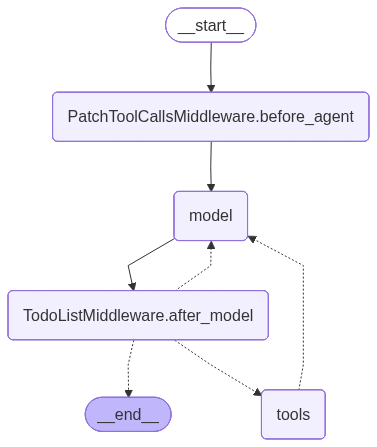

In [ ]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="ollama:glm-4.7:cloud",
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [4]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='eb2c020e-3362-424a-ae15-4e1f0f26b342'),
  AIMessage(content='A deep agent is an AI assistant that uses tools to accomplish tasks autonomously. Unlike simple chatbots that only generate text, deep agents can:\n\n- **Execute actions** through tools (file operations, web searches, computations, etc.)\n- **Plan and reason** about multi-step problems\n- **Iterate** on solutions until tasks are complete\n- **Handle complex workflows** by breaking them into manageable steps\n\nThe "deep" refers to the agent\'s ability to go beyond surface-level conversation and actually *do* things — manipulate data, interact with systems, solve problems through action rather than just description.\n\nIn this context, I\'m a deep agent with access to filesystem tools, web capabilities, and the ability to spawn subagents for parallel work. I don\'t just answer questions; I complete tasks.', additional_kwarg

## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

Memory `(AGENTS.md)`

This is persistent context that is always loaded when configured.
Use it for things that should matter in every conversation: team conventions, writing style, important rules, user preferences.
Key idea: memory is always injected, so keep it small.

In [6]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md


'# AGENTS.md - Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context through its file system tools\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA deep agent is an agent designed for complex, multi-step, long-horizon work.\nUnlike a simple tool-calling loop, a deep agent is built on LangGraph and is\nmeant to plan, store intermediate work, delegate subproblems, and synthesize\nresults over time.\n\nThe core pillars are:\n\n1. Planning through a todo-writing tool.\n2. File-system-backed context offloading.\n3. Delegation to specialized subagents.\n4. A detailed system prompt that teaches when and how to use the above.\n\n---\n\n## 2. Architecture Overview\n\n```\n                    +-----------------------------+\n                    |         Deep Agent          |\n                    |     create_deep_agent     

In [7]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [8]:
agent = create_deep_agent(
    model="ollama:glm-4.7:cloud",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I am a **deep agent** — an AI assistant built on LangGraph designed for complex, multi-step, long-horizon work.

**What I should follow:**

1. **Plan first** — Use `write_todos` for non-trivial tasks
2. **Offload bulky work** — Store intermediate results in files, not in context
3. **Choose backends wisely** — Don't assume paths are "real" files; understand the backend routing
4. **Delegate subproblems** — Use the `task` tool for isolated independent work
5. **Prefer safer defaults** — Default to `StateBackend()`, escalate to disk/shell only when truly needed
6. **Keep answers concise and grounded** — Synthesize results from files/evidence produced
7. **Treat routed prefixes as contracts** — `/workspace/` and `/memories/` are intentional storage boundaries


In [10]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model="ollama:glm-4.7:cloud",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(), #default state backend
)


In [11]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# AGENTS.md - Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context through its file system tools\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA deep agent is an agent designed for complex, multi-step, long-horizon work.\nUnlike a simple tool-calling loop, a deep agent is built on LangGraph and is\nmeant to plan, store intermediate work, delegate subproblems, and synthesize\nresults over time.\n\nThe core pillars are:\n\n1. Planning through a todo-writing tool.\n2. File-system-backed context offloading.\n3. Delegation to specialized subagents.\n4. A detailed system prompt that teaches when and how to use the above.\n\n---\n\n## 2. Architecture Overview\n\n```\n                    +-----------------------------+\n                    |         Deep Agent          |\n                    |     create_dee

In [12]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

**In my memory:** The `/projects/AGENTS.md` file containing architecture details about Deep Agents—information about planning, filesystem backends, subagents, and project conventions.

**Who I am:** I'm a Deep Agent—an AI assistant built on LangGraph designed for complex, multi-step work. I can plan tasks with todo lists, work with a virtual filesystem (files aren't necessarily on real disk), delegate to subagents with isolated context, and offload bulky content to files instead of bloating conversations.

I operate against a virtual filesystem whose actual storage depends on the configured backend (could be state, local files, a store, or a composite of these).


StoreBackend


This stores files in a LangGraph BaseStore, which makes them durable across threads. This is the right choice for long-term memory, reusable instructions, or any cross-run persistence. For local development you can pass a store such as InMemoryStore, but on LangSmith Deployment you omit store because the platform provisions one automatically. The page emphasizes that for multi-user deployments you should always define a namespace so users or tenants do not share the same storage accidentally.

In [15]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="ollama:glm-4.7:cloud",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

My memory is empty - nothing has been stored yet.

I'm a deep agent, an AI assistant that helps users accomplish tasks using tools. I can interact with a filesystem, read and write files, search for content, and even spawn subagents for complex tasks. My approach is direct and efficient — I prioritize understanding your request first, then taking action without unnecessary explanation.


In [12]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='5f18d12e-c3d4-4482-8e97-6ac51db38d40'),
  AIMessage(content=[{'type': 'text', 'text': 'Memory: none loaded.\n\nWho I am: a deep agent accessed via API. I help with research, coding, file edits, analysis, and multi-step tasks using tools when needed. I aim to be concise, accurate, and action-oriented.', 'annotations': [], 'id': 'msg_08e394e0a265d7e1006a2105401dd881a1a701b0aad022af76', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_08e394e0a265d7e1006a21053f6da481a1875b8358fc08564f', 'created_at': 1780548927.0, 'metadata': {}, 'model': 'gpt-5.4-2026-03-05', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05'}, id='resp_08e394e0a265d7e1006a21053f6da481a1875b8358fc08564f', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6397, 'output_

### FileSystemBackend(local disk)

FilesystemBackend:


This maps agent file operations to real files on your machine or mounted storage under a root_dir. It is useful for local development, coding assistants, CI sandboxes, or persistent volumes. The big warning is that this is real disk access, so secrets and irreversible edits are in scope. The page strongly recommends virtual_mode=True; without it, even setting root_dir is not a real safety boundary. Another important recommendation: do not use FilesystemBackend by itself for most real projects, because Deep Agents also store internal artifacts like /large_tool_results/ and /conversation_history/. If you use only FilesystemBackend, those internal files end up mixed into your project directory.

In [16]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="ollama:glm-4.7:cloud",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

**Who I am:**

I'm a Deep Agent — an AI assistant designed for complex, multi-step, long-horizon work. I'm built on LangGraph and have these core capabilities:

1. **Planning** — I maintain structured todo lists to track progress
2. **File system** — I can read, write, edit, and search files in a virtual filesystem
3. **Subagent delegation** — I can spawn isolated subagents for focused independent tasks
4. **Context offloading** — I store bulky intermediate work in files to keep conversations efficient

**What's in my memory:**

Currently, my memory contains only one file: `/AGENTS.md` — this is my system documentation that explains my architecture, capabilities, and how I should operate.

I don't have any user-specific information, preferences, or interaction history stored yet. I can learn and remember things about you as we interact, and I'll save that information to memory when you share it.

What would you like to work on?


In [21]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'LLM gateways are middleware layers that sit between your application and one or more large language model providers.\n\nThey typically provide a single interface for things like:\n\n- routing requests across multiple model vendors\n- authentication and API key management\n- rate limiting and quotas\n- retries, failover, and fallback models\n- logging, tracing, and observability\n- caching\n- policy enforcement and guardrails\n- cost tracking and optimization\n\nWhy teams use them:\n- avoid vendor lock-in\n- centralize control over model usage\n- improve reliability\n- simplify switching models\n- standardize telemetry and governance\n\nExample:\n- Your app sends one request to the gateway.\n- The gateway decides whether to send it to OpenAI, Anthropic, Google, a local model, or a backup model.\n- It may add caching, redact sensitive data, log usage, and retry on failure.\n\nCommon forms:\n- hosted SaaS gateways\n- self-hosted proxy layers\n- API gateways exte

#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [18]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}


In [19]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [20]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [21]:
agent=create_deep_agent(
    model="ollama:glm-4.7:cloud",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer #memory checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

I have access to 4 specialized skills:

## **aws**
AWS cloud expertise. Use when you need help with:
- AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker)
- Architecture design on AWS
- boto3 / AWS CLI usage
- Cost optimization
- Cloud security best practices

## **langgraph**
LangGraph expertise for building stateful, multi-step agent workflows. Use when you need help with:
- LangGraph, StateGraph, nodes, edges, conditional routing
- Checkpointers, persistence, memory
- Human-in-the-loop patterns
- Subgraphs and streaming
- Building agents with langgraph/langchain

## **python**
Expert Python programming skill. Use when you need help with:
- Writing, debugging, refactoring, explaining, or reviewing Python code
- Python concepts (data structures, OOP, async, decorators, typing, packaging, testing)

## **report-writer**
Report writing skill to generate structured markdown reports. Use this after answering substantive queries to:
- Create a struct

In [22]:
result

{'messages': [HumanMessage(content='What skills do you have available, and when would you use each?', additional_kwargs={}, response_metadata={}, id='58438efa-d9b3-4b74-b293-36676e280ee9'),
  AIMessage(content="I have access to 4 specialized skills:\n\n## **aws**\nAWS cloud expertise. Use when you need help with:\n- AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker)\n- Architecture design on AWS\n- boto3 / AWS CLI usage\n- Cost optimization\n- Cloud security best practices\n\n## **langgraph**\nLangGraph expertise for building stateful, multi-step agent workflows. Use when you need help with:\n- LangGraph, StateGraph, nodes, edges, conditional routing\n- Checkpointers, persistence, memory\n- Human-in-the-loop patterns\n- Subgraphs and streaming\n- Building agents with langgraph/langchain\n\n## **python**\nExpert Python programming skill. Use when you need help with:\n- Writing, debugging, refactoring, explaining, or reviewing Python code\n- Pyth

In [23]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

I'll show you a minimal LangGraph example with conditional routing and memory.
Tool Calls:
  read_file (e1f37beb-edce-4bfe-9b5d-9e16e5dadd89)
 Call ID: e1f37beb-edce-4bfe-9b5d-9e16e5dadd89
  Args:
    file_path: /skills/langgraph/SKILL.md
    limit: 1000
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: langgraph
     3	description: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and ru

In [24]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================

I'll help you set up an EC2 instance in AWS. Let me first read the AWS skill documentation to provide you with the most accurate and comprehensive guidance.
Tool Calls:
  read_file (d3aaefb1-1e72-4186-adfb-c0213bcd5b4d)
 Call ID: d3aaefb1-1e72-4186-adfb-c0213bcd5b4d
  Args:
    file_path: /skills/aws/SKILL.md
    limit: 1000
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: aws
     3	description: AWS cloud expertise. Use when the user asks about AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker), architecture design on AWS, boto3 / AWS CLI usage, cost optimization, or cloud security best practices. Provides decision frameworks, CLI/boto3 workflows, and worked examples.
 

In [25]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

write me a python code to do binary search
================================== Ai Message ==================================

I'll write a Python function for binary search:
Tool Calls:
  write_file (75412f6a-b0f4-4911-a6f4-fdd1d9f81246)
 Call ID: 75412f6a-b0f4-4911-a6f4-fdd1d9f81246
  Args:
    content: def binary_search(arr, target):
    """
    Perform binary search on a sorted array.

    Args:
        arr: A sorted list of elements
        target: The element to search for

    Returns:
        int: Index of target if found, -1 if not found
    """
    left = 0
    right = len(arr) - 1

    while left <= right:
        mid = (left + right) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1


def binary_search_recursive(arr, target, left=0, right=None):
    """
    Perform binary